In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv('/content/heart.csv')

In [30]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [31]:
df.shape

(1025, 14)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [33]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [34]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [35]:
df['target'].value_counts()

,count
target,
1,526
0,499


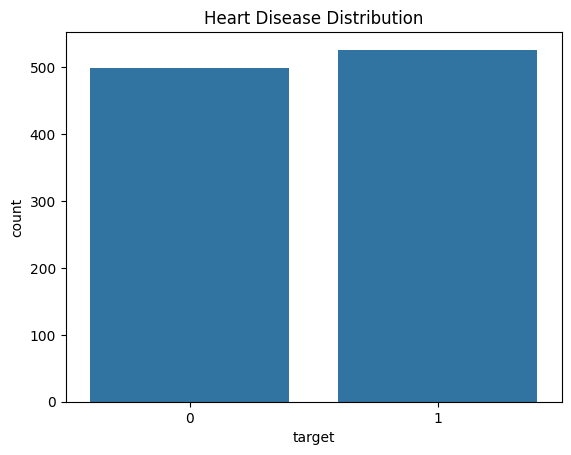

In [36]:
sns.countplot(
x='target',
data=df
)

plt.title(
'Heart Disease Distribution'
)

plt.show()

In [37]:
df['target'].value_counts()

,count
target,
1,526
0,499


Target Variable Analysis:

The dataset is balanced with 526 positive cases and 499 negative cases. This balance helps prevent model bias and improves training quality.

In [38]:
X = df.drop(
'target',
axis=1
)

y = df['target']

In [39]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=(
train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
)

In [40]:
X_train.shape

(820, 13)

In [41]:
X_test.shape

(205, 13)

In [42]:
model1 = LogisticRegression(
max_iter=5000
)

In [43]:
model1.fit(
X_train,
y_train
)

LogisticRegression(max_iter=5000)

In [45]:
y_pred = model1.predict(
X_test
)

In [46]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score
)

print(
"Accuracy:",
accuracy_score(
y_test,
y_pred
)
)

print(
"Precision:",
precision_score(
y_test,
y_pred
)
)

print(
"Recall:",
recall_score(
y_test,
y_pred
)
)

print(
"F1 Score:",
f1_score(
y_test,
y_pred
)
)

Accuracy: 0.7951219512195122
Precision: 0.7563025210084033
Recall: 0.8737864077669902
F1 Score: 0.8108108108108109


In [48]:
model2 = RandomForestClassifier(
n_estimators=100,
random_state=42
)

In [49]:
model2.fit(
X_train,
y_train
)

RandomForestClassifier(random_state=42)

In [50]:
y_pred_rf = model2.predict(
X_test
)

In [51]:
print(
"Accuracy:",
accuracy_score(
y_test,
y_pred_rf
)
)

print(
"Precision:",
precision_score(
y_test,
y_pred_rf
)
)

print(
"Recall:",
recall_score(
y_test,
y_pred_rf
)
)

print(
"F1:",
f1_score(
y_test,
y_pred_rf
)
)

Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1: 0.9852216748768473


In [53]:
model3 = KNeighborsClassifier(
n_neighbors=5
)

In [54]:
model3.fit(
X_train,
y_train
)

KNeighborsClassifier()

In [55]:
y_pred_knn = model3.predict(
X_test
)

In [56]:
print(
"Accuracy:",
accuracy_score(
y_test,
y_pred_knn
)
)

print(
"Precision:",
precision_score(
y_test,
y_pred_knn
)
)

print(
"Recall:",
recall_score(
y_test,
y_pred_knn
)
)

print(
"F1:",
f1_score(
y_test,
y_pred_knn
)
)

Accuracy: 0.7317073170731707
Precision: 0.7307692307692307
Recall: 0.7378640776699029
F1: 0.7342995169082126


In [57]:
comparison = pd.DataFrame({

'Model':[
'Logistic Regression',
'Random Forest',
'KNN'
],

'Accuracy':[
0.795,
0.985,
0.732
],

'Precision':[
0.756,
1.000,
0.731
],

'Recall':[
0.874,
0.971,
0.738
],

'F1':[
0.811,
0.985,
0.734
]

})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.795,0.756,0.874,0.811
1,Random Forest,0.985,1.000,0.971,0.985
2,KNN,0.732,0.731,0.738,0.734


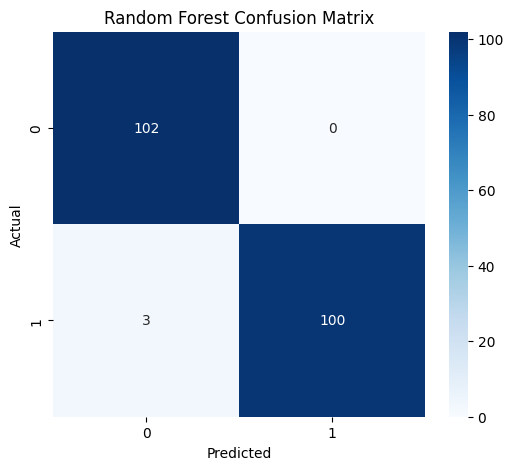

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
y_test,
y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.title(
'Random Forest Confusion Matrix'
)

plt.xlabel(
'Predicted'
)

plt.ylabel(
'Actual'
)

plt.show()

# Conclusion

This project developed and evaluated three machine learning models for heart disease prediction. Logistic Regression achieved balanced performance, while KNN produced lower accuracy. Random Forest delivered the best overall performance with 98.5% accuracy, 100% precision, and 98.5% F1 score. The comparison demonstrated that ensemble learning can significantly improve prediction quality for healthcare datasets.

